# Jupyter version of the code to calculate ASC speed along contour

In [1]:
# Standard modules
import intake
import matplotlib.pyplot as plt
import netCDF4 as nc
import seaborn as sns
import xarray as xr
import numpy as np
import os
from dask.distributed import Client
import cf_xarray as cf
# Optional modules
import xgcm

import dask

This code only runs efficiently on the hugemembw queue

In [2]:
client = Client(threads_per_worker = 1)

In [3]:
catalog = intake.cat.access_nri

In [4]:
expt = 'panant-005-zstar-ACCESSyr2'
lat_slice = slice(-90, -57.6)

In [5]:
start_time='2000-01-01'
end_time='2000-02-01'
time_slice=slice(start_time,end_time)

In [6]:
#importing SIC
u = catalog[expt].search(variable="uo", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True}).uo.cf.sel(latitude=lat_slice).sel(time=time_slice)
v = catalog[expt].search(variable="vo", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True}).vo.cf.sel(latitude=lat_slice).sel(time=time_slice)



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


Here, the data in u and v still have mistmat he x,y dimension sizes

In [7]:
		cutout_latind = int(np.size(u.yh))
		cutout_latind

1073

In [8]:
#importing variables for transposing
V01_dir = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/slope_transpose_panan005.nc'
V01=xr.open_dataset(V01_dir)

slope_u=V01['slope(U-grid)']
slope_v=V01['slope(V-grid)']
dhu_dx_u=V01['dhu_dx(U-grid)']
dhu_dx_v=V01['dhu_dx(V-grid)']
dhu_dy_u=V01['dhu_dy(U-grid)']
dhu_dy_v=V01['dhu_dy(V-grid)']

In [9]:
	yearinit = 1958
	imonth = str(1)
	monthseries=['01','02','03','04','05','06','07','08','09','10','11','12']
	dayseries=['31','28','31','30','31','30','31','31','30','31','30','31'] 
	mi=0
	isobath_depth = 1000

In [10]:
		u_onv=u.interp(xq=v.xh,yh=v.yq)
		v_onu=v.interp(xh=u.xq,yq=u.yh)

In [11]:
# Cutting all matrices so their grid match
if expt != 'panant-0025-zstar-ACCESSyr2':
    xmaxq=int(np.size(u.xq))
    u=u.isel(xq=slice(1,xmaxq))#.rename({'z_l_sub01':'z_l'})
    v_onu=v_onu.isel(xq=slice(1,xmaxq))#.rename({'z_l_sub01':'z_l'})
    #v=v.rename({'z_l_sub01':'z_l'})
    #u_onv=u_onv.rename({'z_l_sub01':'z_l'})
else:
    xmaxq=int(np.size(u.xq))
    u=u.isel(xq=slice(1,xmaxq))
    v_onu=v_onu.isel(xq=slice(1,xmaxq))
    v=v
    u_onv=u_onv

In [12]:
umean = u.mean('time').isel(z_l=0).rename({'yh':'y','xq':'x'})
umean_onv = u_onv.mean('time').isel(z_l=0).rename({'yq':'y','xh':'x'})
umean=umean.combine_first(umean_onv)#.fillna(0)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 25
  result = blockwise(


In [13]:
# umean = umean.sel(y=data_xr.lat_along_contour,x=data_xr.lon_along_contour)

In [14]:
# plt.plot(lon_along_contour,umean)

In [15]:
		############################ Along-slope velocity
		U_along_ug = u*dhu_dy_u/slope_u - v_onu*dhu_dx_u/slope_u
		U_along_vg = u_onv*dhu_dy_v/slope_v - v*dhu_dx_v/slope_v

In [16]:
		# ############################ Along-slope velocity
		# U_along_ug = u*dhu_dx_u/slope_u - v_onu*dhu_dy_u/slope_u
		# U_along_vg = u_onv*dhu_dx_v/slope_v - v*dhu_dy_v/slope_v

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 48
  result = blockwise(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 45
  result = blockwise(


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 215.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide


(-80.0, -63.0)

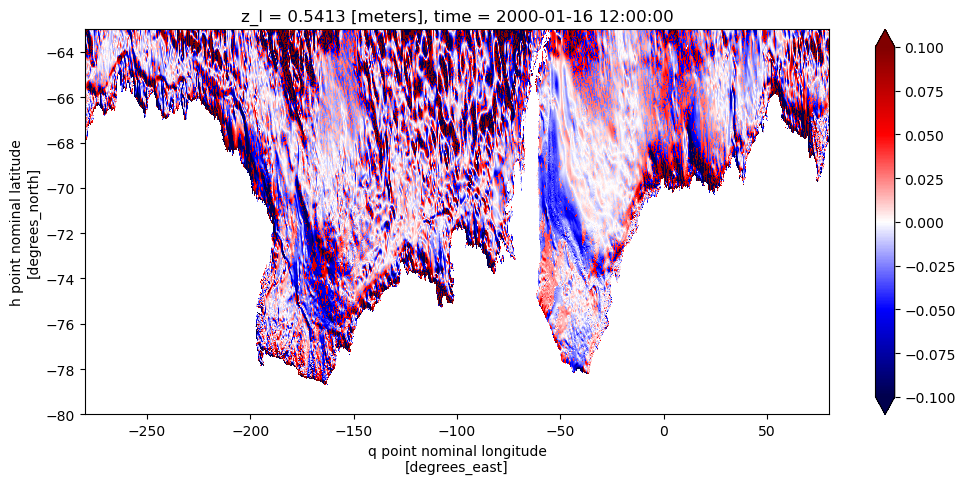

In [17]:
plt.figure(figsize = (12,5))
U_along_ug.isel(time=0,z_l=0).plot(vmin=-.1,vmax=.1,cmap='seismic')
plt.ylim(-80,-63)

In [18]:
		V_cross_ug = u*dhu_dx_u/slope_u + v_onu*dhu_dy_u/slope_u
		V_cross_vg = u_onv*dhu_dx_v/slope_v + v*dhu_dy_v/slope_v

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 48
  result = blockwise(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 45
  result = blockwise(


I noticed the resulting transposed maps have a different size for the vertical coordinate. That might be a problem with the ggrid - uou will have to recheck it.

In [19]:
%%time
U_along0_vg=U_along_vg.compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 211.08 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide


CPU times: user 7min 44s, sys: 1min 54s, total: 9min 38s
Wall time: 9min 48s


In [20]:
%%time
U_along0_ug=U_along_ug.compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 216.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 8min 44s, sys: 2min, total: 10min 45s
Wall time: 10min 54s


In [21]:
# Load the isobath information
CSHT = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/CSHT_month_rhoonline/Ant_cross_slope_heat_terms_offline_700m_1999-01.nc').drop('time')
umean_c = umean.sel(x=CSHT.lon_along_contour,y=CSHT.lat_along_contour)


/jobfs/150364952.gadi-pbs/ipykernel_3685610/3322265102.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  CSHT = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/CSHT_month_rhoonline/Ant_cross_slope_heat_terms_offline_700m_1999-01.nc').drop('time')


In [22]:
		########### Import panan01 contour
		outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan005_1000m.npz'
		data = np.load(outfile)
		mask_y_transport = data['mask_y_transport']; 
		mask_y_transport=mask_y_transport[:cutout_latind,:]       ##############################
		mask_x_transport = data['mask_x_transport']; 
		mask_x_transport=mask_x_transport[:cutout_latind,:]		################################
		mask_y_transport_numbered = data['mask_y_transport_numbered']
		mask_y_transport_numbered=mask_y_transport_numbered[:cutout_latind,:]		################################
		mask_x_transport_numbered = data['mask_x_transport_numbered']
		mask_x_transport_numbered=mask_x_transport_numbered[:cutout_latind,:]		################################
		
		
		#cutting the matrices
		ylength= np.shape(mask_x_transport)[0]
		
		
		#yt_ocean0 = cc.querying.getvar(expt,'yh',session,n=1)
		yt_ocean0 = u.yh.isel(yh=slice(0,ylength))
		#yu_ocean0 = cc.querying.getvar(expt,'yq',session,n=1)
		yu_ocean0 = v.yq.isel(yq=slice(1,ylength+1))
		xt_ocean0 = v.xh
		xu_ocean0 = u.xq#[1:]


In [23]:
import warnings

In [24]:
warnings.filterwarnings("ignore")

mask_x_transport =xr.DataArray(data['mask_x_transport']).assign_coords({"dim_0": np.array(yt_ocean0),"dim_1": np.array(xu_ocean0)}).rename(dim_0="y_ocean",dim_1="x_ocean")
mask_x_transport=mask_x_transport[:cutout_latind,:]       ##############################
mask_y_transport =xr.DataArray(data['mask_y_transport']).assign_coords({"dim_0": np.array(yt_ocean0),"dim_1": np.array(xu_ocean0)}).rename(dim_0="y_ocean",dim_1="x_ocean")
mask_y_transport=mask_y_transport[:cutout_latind,:]		################################		
mask_x_transport_numbered =xr.DataArray(data['mask_x_transport_numbered']).assign_coords({"dim_0": np.array(yt_ocean0),"dim_1": np.array(xu_ocean0)}).rename(dim_0="y_ocean",dim_1="x_ocean")          ##################
mask_x_transport_numbered=mask_x_transport_numbered[:cutout_latind,:]		################################		
mask_y_transport_numbered =xr.DataArray(data['mask_y_transport_numbered']).assign_coords({"dim_0": np.array(yu_ocean0),"dim_1": np.array(xt_ocean0)}).rename(dim_0="y_ocean",dim_1="x_ocean")          ##################
mask_y_transport_numbered=mask_y_transport_numbered[:cutout_latind,:]		################################

num_points = int(np.maximum(np.max(mask_y_transport_numbered),np.max(mask_x_transport_numbered)))                
                




############### Getting the lon,lat along contour in the X,Y contour
lat_along_contour = np.zeros((num_points))
lon_along_contour = np.zeros((num_points))
# locations for zonal transport:
x_indices_masked = mask_x_transport_numbered.stack().values
x_indices = np.sort(x_indices_masked[x_indices_masked>0])
for count in x_indices:
    count = int(count)
    jj = int(np.where(mask_x_transport_numbered==count)[0])
    ii = int(np.where(mask_x_transport_numbered==count)[1])   
    lon_along_contour[count-1] = xu_ocean0[ii].values
    lat_along_contour[count-1] = mask_x_transport_numbered.y_ocean[jj].values
    
# locations for meridional transport:
y_indices_masked = mask_y_transport_numbered.stack().values
y_indices = np.sort(y_indices_masked[y_indices_masked>0])
for count in y_indices:
    count = int(count)
    jj = np.where(mask_y_transport_numbered==count)[0]
    ii = np.where(mask_y_transport_numbered==count)[1]
    lon_along_contour[count-1] = mask_x_transport_numbered.x_ocean[ii].values           ##################          ##################          ##################          ##################          ##################          ##################
    lat_along_contour[count-1] = yu_ocean0[jj].values

In [25]:
warnings.filterwarnings("default")

In [26]:
		U_along0_ug=U_along0_ug.rename(yh='y_ocean',xq='x_ocean')
		U_along0_vg=U_along0_vg.rename(yq='y_ocean',xh='x_ocean')

In [27]:
# U_along0_ug.name='u'
# U_along0_vg.name='u'
Ualong_2grids =U_along0_ug.copy().drop_vars(('xh','yq'))

In [28]:
#trying a different combination of combine_first between the two grids + sel the lons and lats we want

Ualong_2grids = Ualong_2grids.combine_first(U_along0_vg.drop_vars(('xq','yh')))

#  xr.combine_first(U_along0_ug.drop_vars(('xh','yq')),U_along0_vg.drop_vars(('xq','yh'))) 

In [47]:
#extract data along the contour
Ualong_extracted = Ualong_2grids.sel(y_ocean=CSHT.lat_along_contour,x_ocean=CSHT.lon_along_contour)
#deptho = cc.querying.getvar(expt, 'deptho', session,n=1)
deptho = catalog[expt].search(variable="deptho").to_dask(xarray_open_kwargs={'decode_timedelta':True}).deptho.cf.sel(latitude=lat_slice).compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only fi

It seems that the problem is in the values along the contour itself. I am not sure why tho. how can we figure it out?

The u velocities do seem to be negative along the contour, but they get an oscillation between positive and negative when transposed from xy, to along coordinate. this tells me we have a problem in the transposition

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 67.90 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


(-74.0, -62.5)

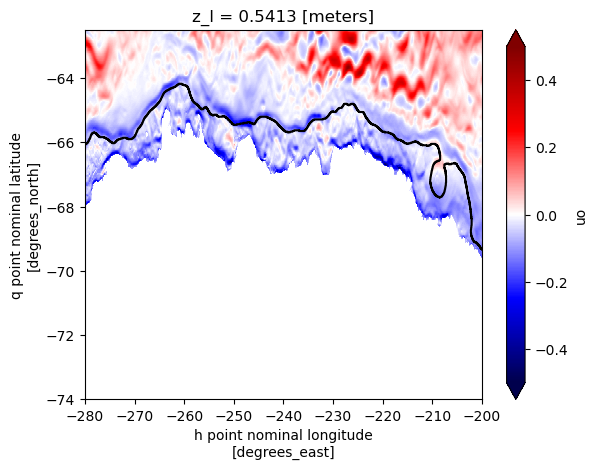

In [30]:
umean_onv.plot(cmap='seismic',vmin=-.5,vmax=.5)
plt.plot(CSHT.lon_along_contour,CSHT.lat_along_contour,color='k')
plt.xlim(-280,-200);plt.ylim(-74,-62.5)

(-74.0, -62.5)

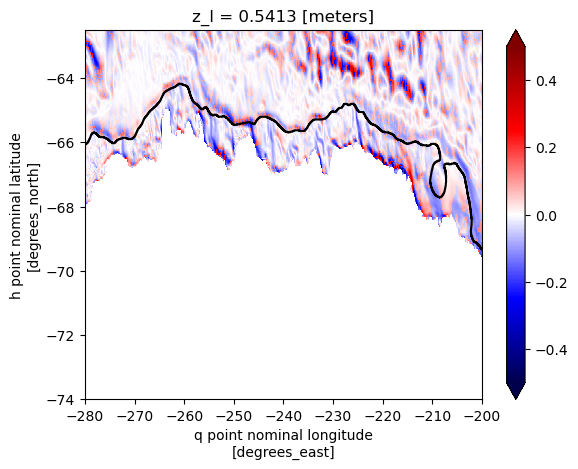

In [31]:
U_along0_ug.mean('time').isel(z_l=0).plot(cmap='seismic',vmin=-.5,vmax=.5)
plt.plot(CSHT.lon_along_contour,CSHT.lat_along_contour,color='k')
plt.xlim(-280,-200);plt.ylim(-74,-62.5)

(-74.0, -62.5)

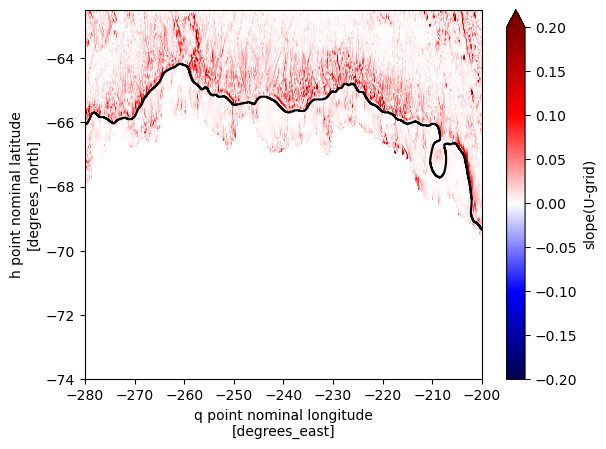

In [32]:
slope_u.plot(cmap='seismic',vmin=-.2,vmax=.2)
plt.plot(CSHT.lon_along_contour,CSHT.lat_along_contour,color='k')
plt.xlim(-280,-200);plt.ylim(-74,-62.5)

(-74.0, -62.5)

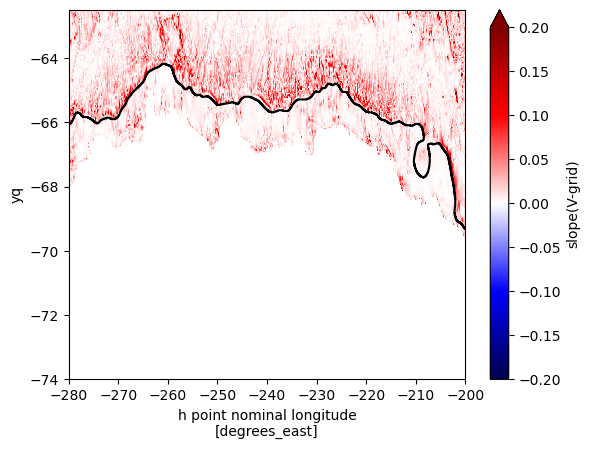

In [33]:
slope_v.plot(cmap='seismic',vmin=-.2,vmax=.2)
plt.plot(CSHT.lon_along_contour,CSHT.lat_along_contour,color='k')
plt.xlim(-280,-200);plt.ylim(-74,-62.5)

(-74.0, -62.5)

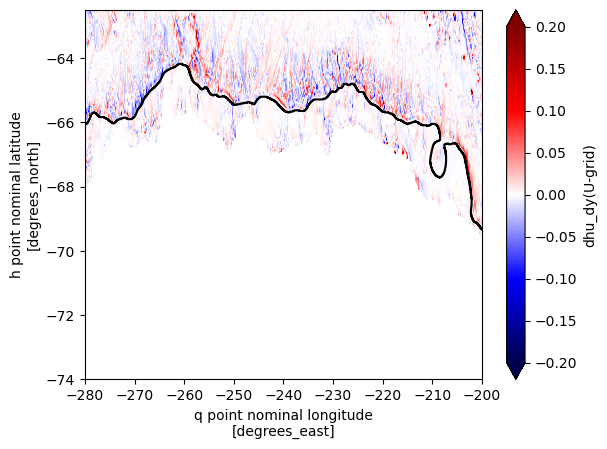

In [34]:
dhu_dy_u.plot(cmap='seismic',vmin=-.2,vmax=.2)
plt.plot(CSHT.lon_along_contour,CSHT.lat_along_contour,color='k')
plt.xlim(-280,-200);plt.ylim(-74,-62.5)

(-74.0, -62.5)

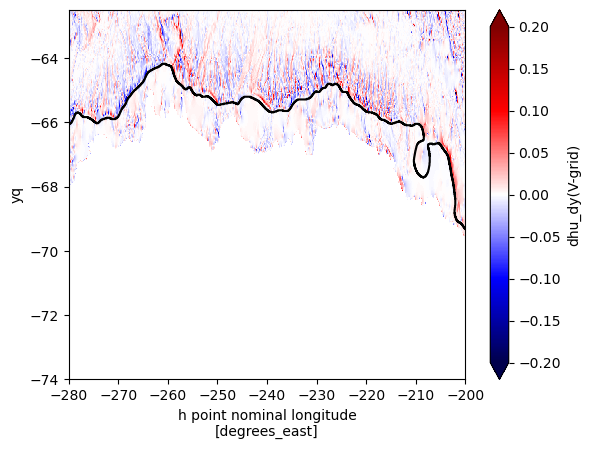

In [35]:
dhu_dy_v.plot(cmap='seismic',vmin=-.2,vmax=.2)
plt.plot(CSHT.lon_along_contour,CSHT.lat_along_contour,color='k')
plt.xlim(-280,-200);plt.ylim(-74,-62.5)

it seems tom me that the problem comes from dhu_dx/y

In [36]:
# Create the contour order data-array. Note that in this procedure the x-grid counts have x-grid
#   dimensions and the y-grid counts have y-grid dimensions, but these are implicit, the dimension 
#   *names* are kept general across the counts, the generic y_ocean, x_ocean, so that concatening works
#   but we dont double up with numerous counts for one lat/lon point.

# stack contour data into 1d:
mask_x_numbered_1d = mask_x_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
mask_x_numbered_1d = mask_x_numbered_1d.where(mask_x_numbered_1d > 0, drop = True)

mask_y_numbered_1d = mask_y_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
mask_y_numbered_1d = mask_y_numbered_1d.where(mask_y_numbered_1d > 0, drop = True)

contour_ordering = xr.concat((mask_x_numbered_1d, mask_y_numbered_1d), dim = 'contour_index')
contour_ordering = contour_ordering.sortby(contour_ordering)
contour_index_array = np.arange(1, len(contour_ordering)+1)

In [37]:
%%time
## We could also loop in time if we didn't want the time average. Initialise a data array and fill in data by looping in time.

# stack transports into 1d and drop any points not on contour:
x_along_1d = U_along0_ug.drop_vars('xh').drop_vars('yq').stack(contour_index = ['y_ocean', 'x_ocean'])
x_along_1d = x_along_1d.where(mask_x_numbered_1d>0, drop = True)
y_along_1d = U_along0_vg.drop_vars('xq').drop_vars('yh').stack(contour_index = ['y_ocean', 'x_ocean'])
y_along_1d = y_along_1d.where(mask_y_numbered_1d>0, drop = True)

# # # combine all points on contour:
Ualong = xr.concat((x_along_1d, y_along_1d), dim = 'contour_index')
Ualong = Ualong.sortby(contour_ordering)
Ualong.coords['contour_index'] = contour_index_array
# Ualong = Ualong.load()

CPU times: user 1.64 s, sys: 962 ms, total: 2.6 s
Wall time: 1.66 s


<timed exec>:12: FutureWarning: updating coordinate 'contour_index' with a PandasMultiIndex would leave the multi-index level coordinates ['y_ocean', 'x_ocean'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['contour_index', 'y_ocean', 'x_ocean'])` before assigning new coordinate values.


In [38]:
%%time
#timing test
V_cross0_ug,V_cross0_vg = dask.compute(V_cross_ug,V_cross_vg)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 360.66 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide


CPU times: user 18min 21s, sys: 4min 17s, total: 22min 39s
Wall time: 22min 57s


In [39]:
		# %%time
		# V_cross0_ug = V_cross_ug.compute()
		# V_cross0_vg = V_cross_vg.compute()

In [40]:
		V_cross0_ug = V_cross0_ug.rename(yh='y_ocean',xq='x_ocean')
		V_cross0_vg = V_cross0_vg.rename(yq='y_ocean',xh='x_ocean')

In [41]:
%%time
## We could also loop in time if we didn't want the time average. Initialise a data array and fill in data by looping in time.

# stack transports into 1d and drop any points not on contour:
x_cross_1d = V_cross0_ug.drop_vars('xh').drop_vars('yq').stack(contour_index = ['y_ocean', 'x_ocean'])
x_cross_1d = x_cross_1d.where(mask_x_numbered_1d>0, drop = True)
y_cross_1d = V_cross0_vg.drop_vars('xq').drop_vars('yh').stack(contour_index = ['y_ocean', 'x_ocean'])
y_cross_1d = y_cross_1d.where(mask_y_numbered_1d>0, drop = True)

# combine all points on contour:
Ucross = xr.concat((x_cross_1d, y_cross_1d), dim = 'contour_index')
Ucross = Ucross.sortby(contour_ordering)
Ucross.coords['contour_index'] = contour_index_array
Ucross = Ucross.load()

CPU times: user 6.1 s, sys: 805 ms, total: 6.91 s
Wall time: 5.84 s


<timed exec>:12: FutureWarning: updating coordinate 'contour_index' with a PandasMultiIndex would leave the multi-index level coordinates ['y_ocean', 'x_ocean'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['contour_index', 'y_ocean', 'x_ocean'])` before assigning new coordinate values.


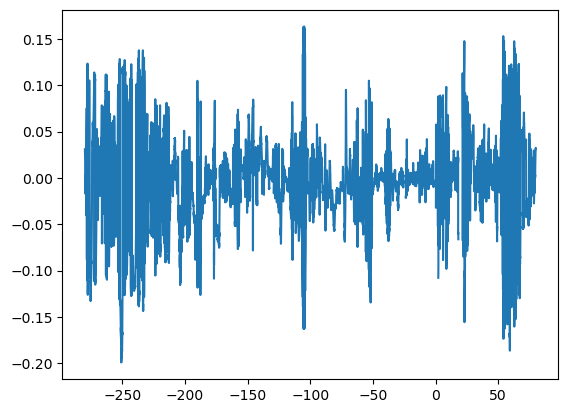

In [42]:
plt.plot(lon_along_contour,Ualong.mean('z_l').mean('time'))

/jobfs/150364952.gadi-pbs/ipykernel_3685610/3377313539.py:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(lon_along_contour,Ualong.z_l,Ualong.mean('time'),vmin=-0.2,vmax=0.2,cmap='seismic')


(1200.0, 0.0)

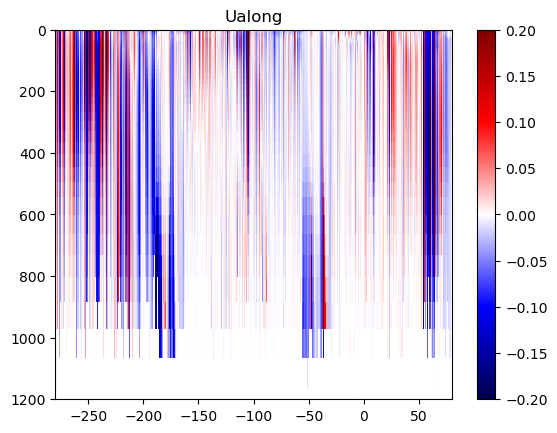

In [43]:
plt.pcolormesh(lon_along_contour,Ualong.z_l,Ualong.mean('time'),vmin=-0.2,vmax=0.2,cmap='seismic')
plt.colorbar()
plt.title('Ualong')
plt.ylim(1200,0)

/jobfs/150364952.gadi-pbs/ipykernel_3677981/3842143867.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(previous_u.lon_along_contour,previous_u.z_l,previous_u_annual_mean.u_along_contour.mean('time'),vmin=-0.2,vmax=0.2,cmap='seismic')


(1200.0, 0.0)

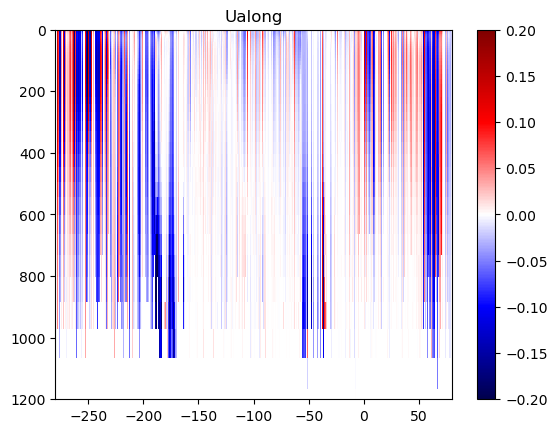

In [63]:
#test
previous_u = xr.open_dataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/ASC_speed/daily_z/Antarctic_slope_contour_1km_velocities_2000-01-01_uv.nc')
previous_u_annual_mean = xr.open_mfdataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/ASC_speed/daily_z/Antarctic_slope_contour_1km_velocities_2000*_uv.nc')

plt.pcolormesh(previous_u.lon_along_contour,previous_u.z_l,previous_u_annual_mean.u_along_contour.mean('time'),vmin=-0.2,vmax=0.2,cmap='seismic')
plt.colorbar()
plt.title('Ualong')
plt.ylim(1200,0)

In [67]:
src_OM2 = '/g/data/x77/wf4500/ASC_project/ASC_speed/monthly/OM2_RYF/Antarctic_slope_contour_1km_velocities_20*'
# ##importing data from ocean.nc
u_OM2=xr.open_mfdataset(src_OM2, concat_dim='time', combine='nested')

# Along_slope_v_time=xr.open_mfdataset(gl, concat_dim='time', combine='nested')

/jobfs/150364952.gadi-pbs/ipykernel_3677981/1982392037.py:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(lon_along_contour,Ualong.z_l,Ucross.isel(time=0),vmin=-0.3,vmax=0.3,cmap='seismic')


(1200.0, 0.0)

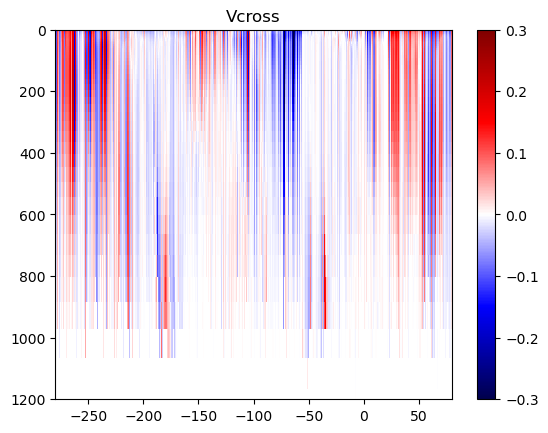

In [56]:

plt.pcolormesh(lon_along_contour,Ualong.z_l,Ucross.isel(time=0),vmin=-0.3,vmax=0.3,cmap='seismic')
plt.title('Vcross')
plt.colorbar()
plt.ylim(1200,0)

**I remenber Adele mentioning a problem in OM2 in the Antarctic Peninsula (regarding a reverse undercurrent). Maybe the difference we see in the Antarctic peninsula comes from it? Read more about it!**

In [ ]:
         
		        
		# # PREVIOUS SAVEDIR TO LOCATE THE FILES save_dir  = '/g/data/x77/wf4500/ASC_project/ASC_speed/monthly/OM2_RYF/'
		# save_dir  = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/ASC_speed/daily_z/'        
		# file_name = 'Antarctic_slope_contour_1km_velocities_'
		
		# data_u=xr.DataArray((Ualong),name="u_along_contour",dims=["time","z_l","contour_index"])
		# data_v=xr.DataArray((Ucross),name="u_cross_contour",dims=["time","z_l","contour_index"])
		# data_lon=xr.DataArray((lon_along_contour),name="lon_along_contour",dims=["contour_index"])
		# data_lat=xr.DataArray((lat_along_contour),name="lat_along_contour",dims=["contour_index"])
		
		# data_to_saveuv = xr.merge([data_u,data_v,data_lon,data_lat])
		# data_to_saveuv['contour_index']=Ualong.contour_index
		# data_to_saveuv['z_l']=np.array(Ualong.z_l)
		# data_to_saveuv['time']=Ualong.time
		# data_to_saveuv
		# data_to_saveuv.to_netcdf(save_dir + file_name + start_time +"_uv.nc")




In [ ]:
start_time

'2000-11-01'